In [2]:
import numpy as np

arr = [0,1,2,3,4,5]
arr = np.array(arr)
arr_rev = arr[::-1]
print(arr_rev[:2])

[5 4]


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
import Stellar_sim_t_dep as SSTD

import importlib
importlib.reload(SSTD)

import numpy as np
import matplotlib.pyplot as plt

[CudaDevice(id=0)]
gpu
[CudaDevice(id=0)]
gpu


In [4]:
# [m22, r_half[Kpc], no_of_particles, no_time_steps, total_evolve_time[Gyr], r_min[pc], r_max_enclosing_frac, no_radius_bins]

first_sim = SSTD.StellarSimTDep(m22 = 1, r_half = 0.19, no_of_particles = 1, no_time_steps = 10, total_evolve_time = 5, r_min = 20, r_max_enclosing_frac = 0.99, no_radius_bins = 1000, animate=True)


In [5]:
first_sim.run_simulation()

l max from jaxsp: 23
Animation enabled: density shell at r = 0.1902 kpc
Time step 2 / 10
Time step 3 / 10
Time step 4 / 10
Time step 5 / 10
Time step 6 / 10
Time step 7 / 10
Time step 8 / 10
Time step 9 / 10
Time step 10 / 10


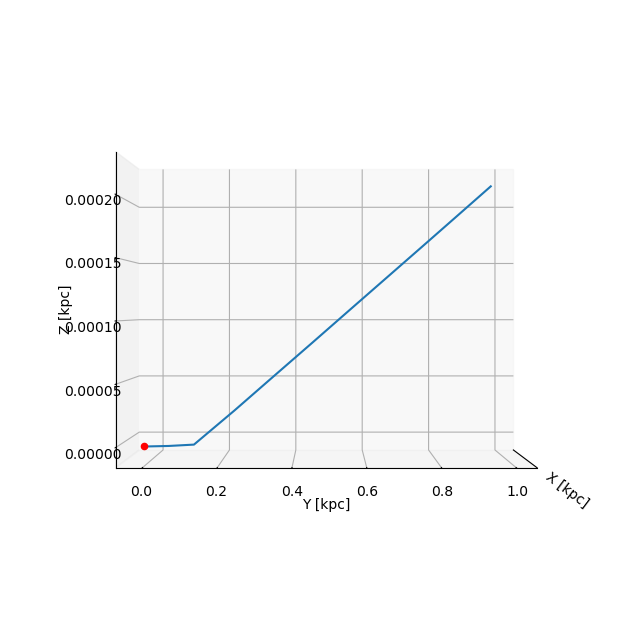

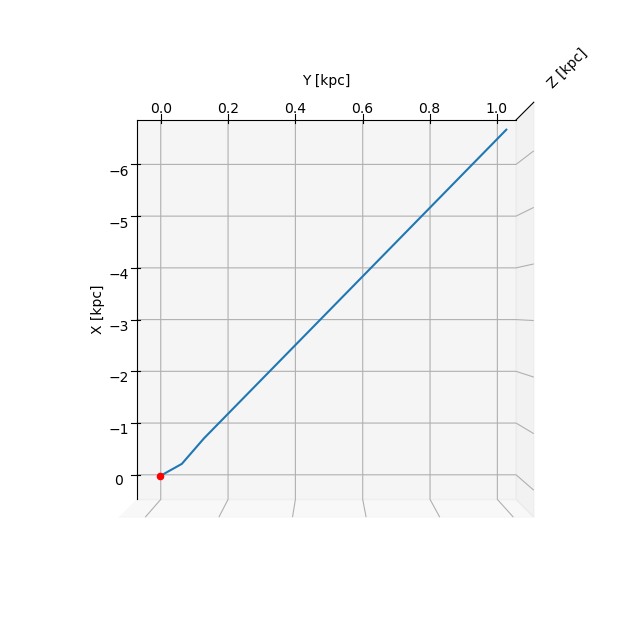

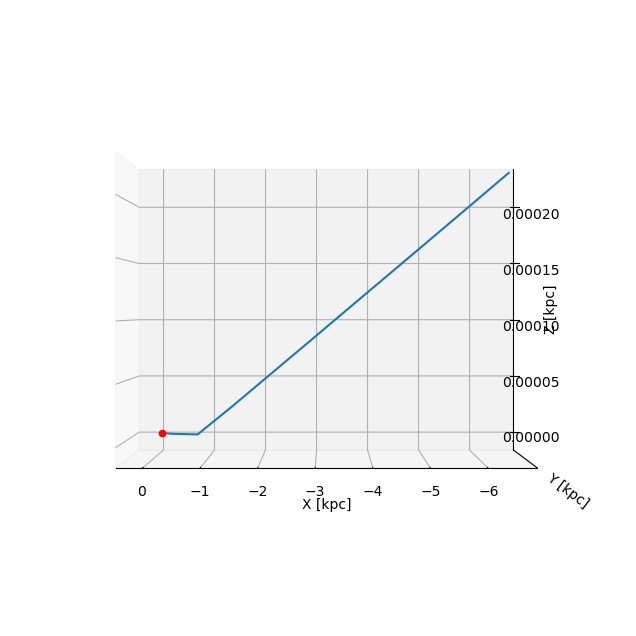

In [6]:


pos = np.array(first_sim.positions_xyz)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=0, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_xticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=90, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_zticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=0, azim=90)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_yticks([])
plt.show()


In [ ]:
ani = first_sim.animator.create_animation(save_path="/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/stellar_simulation_1000.gif")


MovieWriter ffmpeg unavailable; using Pillow instead.


Animation saved to /home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/stellar_simulation_1000.gif


In [8]:

velocities = np.array(first_sim.velocities)
stellar_v_disp = np.array(first_sim.stellar_v_disp) 
average_r = np.array(first_sim.average_r)
r_values = np.array(first_sim.r_values)
time_step = first_sim.time_step

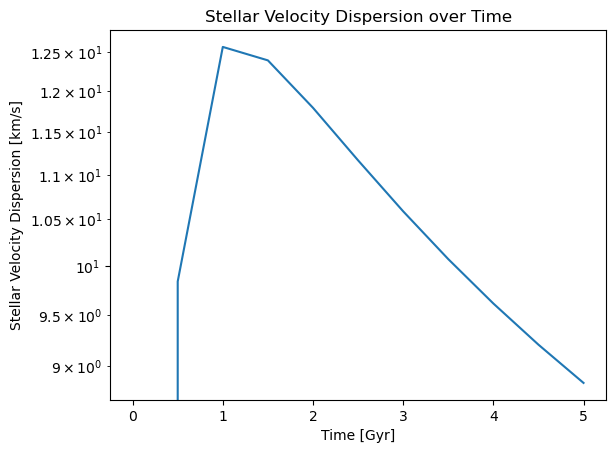

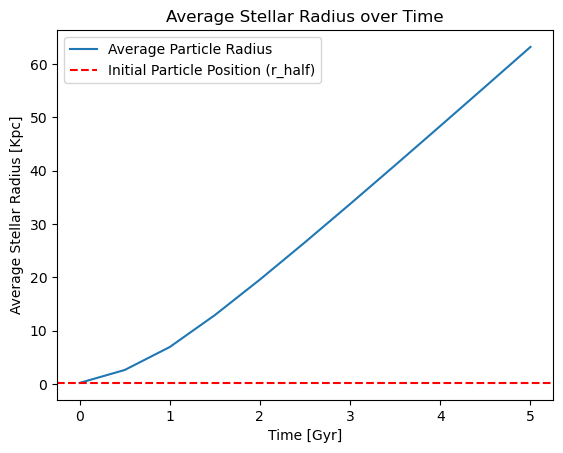

In [9]:


x = np.linspace(0, time_step, len(stellar_v_disp))

plt.plot(x * first_sim.dt * first_sim.u.to_Gyr, stellar_v_disp * first_sim.u.to_kms)
plt.yscale('log')
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

plt.plot(x * first_sim.dt * first_sim.u.to_Gyr, average_r * first_sim.u.to_Kpc, label='Average Particle Radius')
#plt.plot(x * first_sim.dt * first_sim.u.to_Gyr, r_values * first_sim.u.to_Kpc, label='Particle radial position')
plt.axhline(first_sim.r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
plt.xlabel('Time [Gyr]')
plt.ylabel('Average Stellar Radius [Kpc]')
plt.title('Average Stellar Radius over Time')
plt.legend()
plt.show()

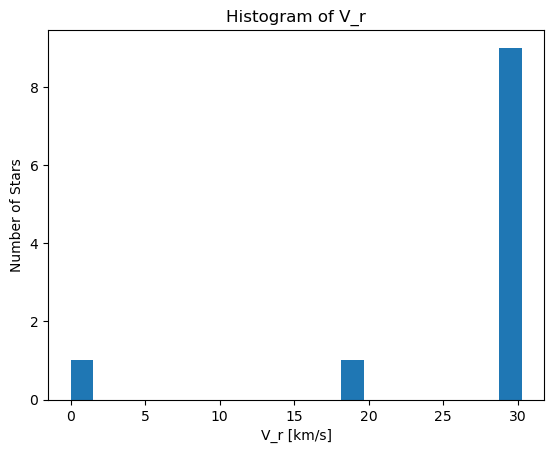

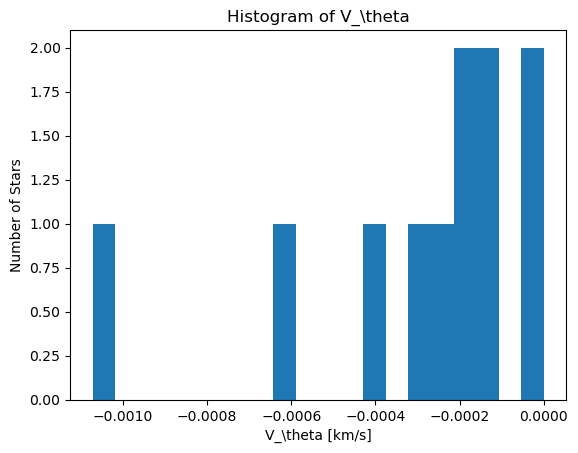

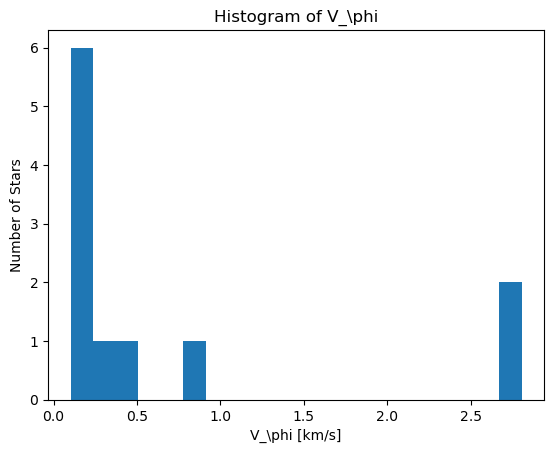

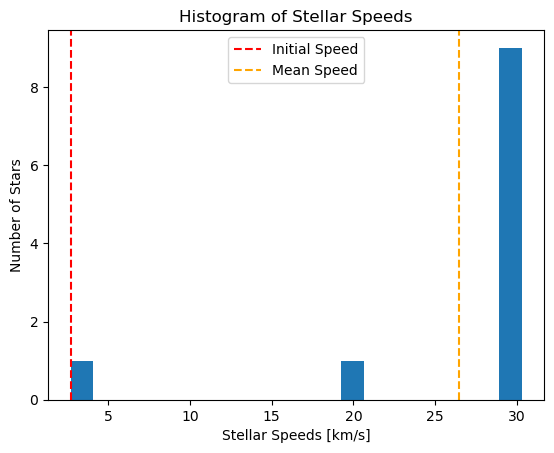

In [10]:
speeds = np.sqrt(velocities[:,0]**2 + velocities[:,1]**2 + velocities[:,2]**2)

first_speed = speeds[0]
first_vel = velocities[0]


plt.hist(velocities[:,0] * first_sim.u.to_kms, bins=20, label='Vr')
plt.xlabel(r'V_r [km/s]')
plt.ylabel('Number of Stars')
plt.title(r'Histogram of V_r')
plt.show()

plt.hist(velocities[:,1] * first_sim.u.to_kms, bins=20, label='Vtheta')
plt.xlabel(r'V_\theta [km/s]')
plt.ylabel('Number of Stars')
plt.title(r'Histogram of V_\theta')
plt.show()

plt.hist(velocities[:,2] * first_sim.u.to_kms, bins=20, label='Vphi')
plt.xlabel(r'V_\phi [km/s]')
plt.ylabel('Number of Stars')
plt.title(r'Histogram of V_\phi')
plt.show()

plt.hist(speeds * first_sim.u.to_kms, bins=20)
plt.axvline(first_speed * first_sim.u.to_kms, color='r', linestyle='--', label='Initial Speed')
plt.axvline(np.mean(speeds * first_sim.u.to_kms), color='orange', linestyle='--', label='Mean Speed')
plt.xlabel('Stellar Speeds [km/s]')
plt.ylabel('Number of Stars')
plt.title('Histogram of Stellar Speeds')
plt.legend()
plt.show()

In [11]:

importlib.reload(SSTD)

second_sim = SSTD.StellarSimTDep(m22 = 1, r_half = 0.19, no_of_particles = 1, no_time_steps = 20, total_evolve_time = 5, r_min = 20, r_max_enclosing_frac = 0.99, no_radius_bins = 1000, animate=True)


[CudaDevice(id=0)]
gpu


In [12]:
second_sim.run_simulation()



l max from jaxsp: 23
Animation enabled: density shell at r = 0.1902 kpc
Time step 2 / 20
Time step 3 / 20
Time step 4 / 20
Time step 5 / 20
Time step 6 / 20
Time step 7 / 20
Time step 8 / 20
Time step 9 / 20
Time step 10 / 20
Time step 11 / 20
Time step 12 / 20
Time step 13 / 20
Time step 14 / 20
Time step 15 / 20
Time step 16 / 20
Time step 17 / 20
Time step 18 / 20
Time step 19 / 20
Time step 20 / 20


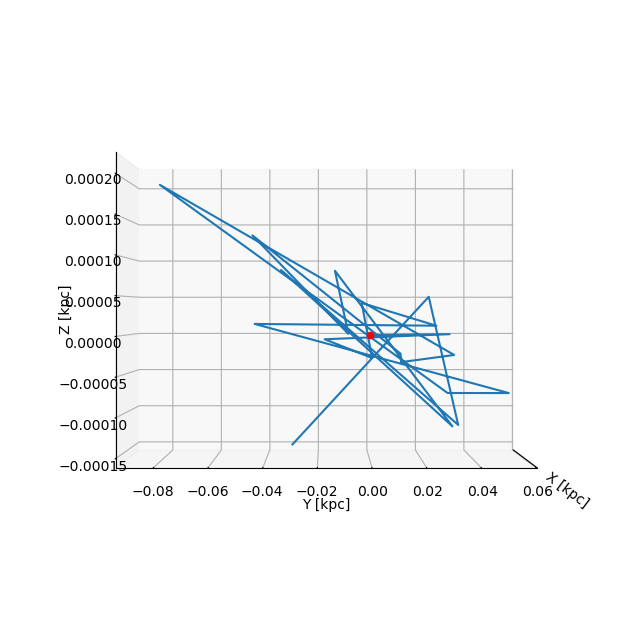

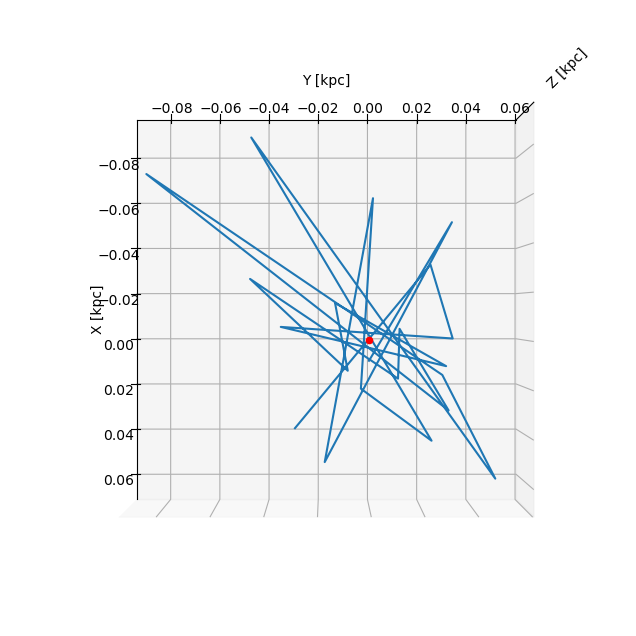

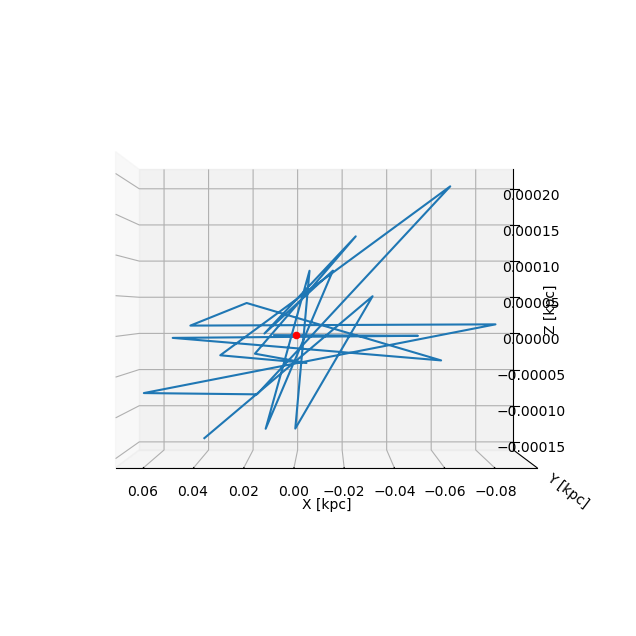

In [13]:

pos = np.array(second_sim.positions_xyz)


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=0, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_xticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=90, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_zticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=0, azim=90)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_yticks([])
plt.show()

In [14]:
ani = second_sim.animator.create_animation(save_path="/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/stellar_simulation_20.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.


Animation saved to /home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/stellar_simulation_20.gif


In [ ]:


velocities2 = np.array(second_sim.velocities)
stellar_v_disp2 = np.array(second_sim.stellar_v_disp)
average_r2 = np.array(second_sim.average_r)
r_values2= np.array(second_sim.r_values)
time_step2 = second_sim.time_step

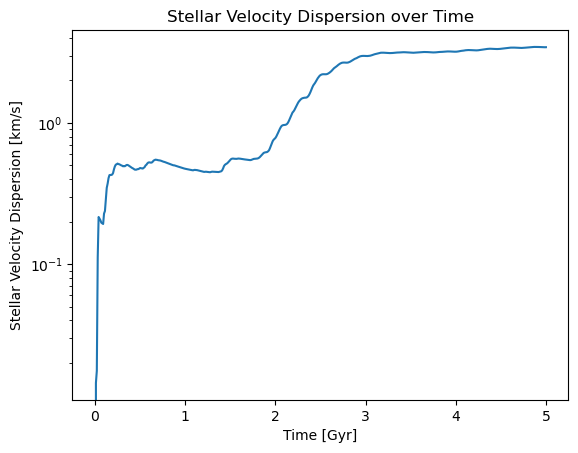

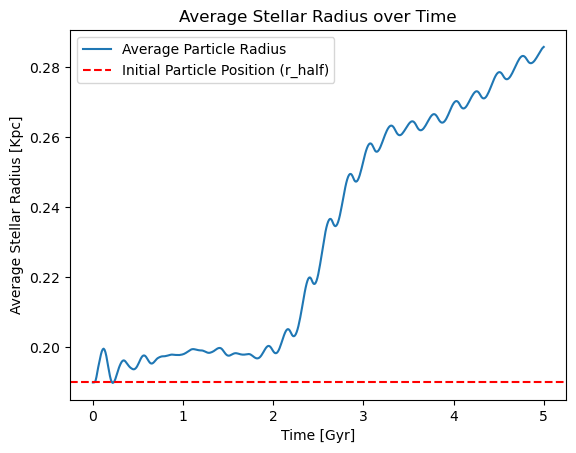

In [ ]:
x = np.linspace(0, time_step2, len(stellar_v_disp2))

plt.plot(x * second_sim.dt * second_sim.u.to_Gyr, stellar_v_disp2 * second_sim.u.to_kms)
plt.yscale('log')
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

plt.plot(x * second_sim.dt * second_sim.u.to_Gyr, average_r2 * second_sim.u.to_Kpc, label='Average Particle Radius')
#plt.plot(x * second_sim.dt * second_sim.u.to_Gyr, r_values2 * second_sim.u.to_Kpc, label='Particle radial position')
plt.axhline(second_sim.r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
plt.xlabel('Time [Gyr]')
plt.ylabel('Average Stellar Radius [Kpc]')
plt.title('Average Stellar Radius over Time')
plt.legend()
plt.show()

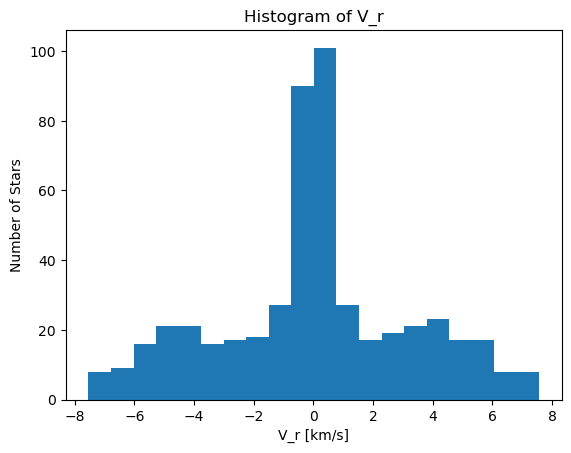

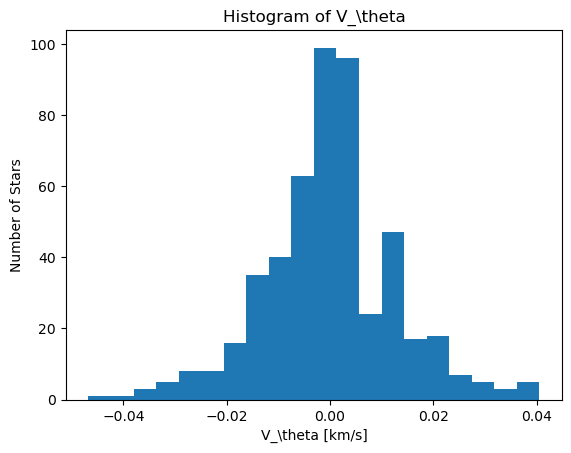

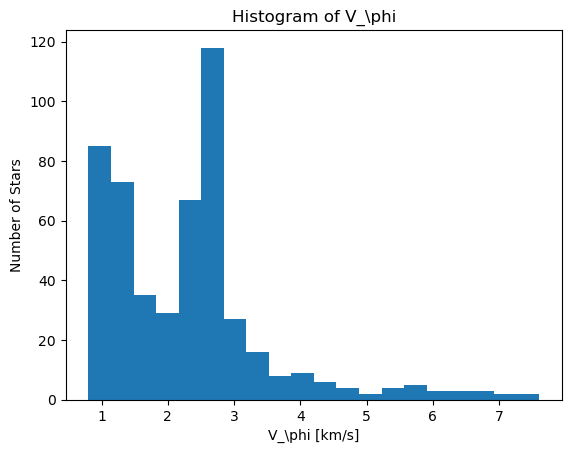

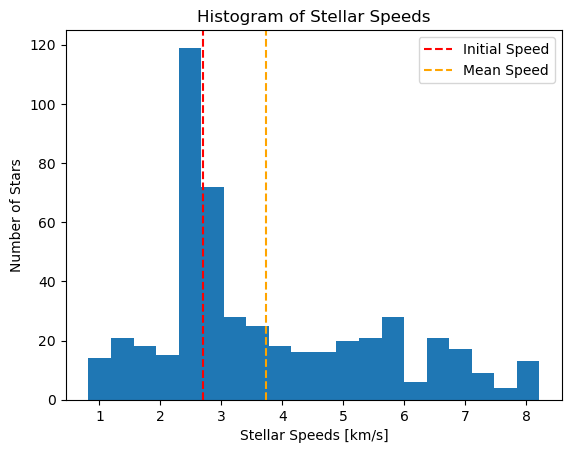

In [ ]:
speeds2 = np.sqrt(velocities2[:,0]**2 + velocities2[:,1]**2 + velocities2[:,2]**2)

first_speed2 = speeds2[0]
first_vel2 = velocities2[0]


plt.hist(velocities2[:,0] * second_sim.u.to_kms, bins=20, label='Vr')
plt.xlabel(r'V_r [km/s]')
plt.ylabel('Number of Stars')
plt.title(r'Histogram of V_r')
plt.show()

plt.hist(velocities2[:,1] * second_sim.u.to_kms, bins=20, label='Vtheta')
plt.xlabel(r'V_\theta [km/s]')
plt.ylabel('Number of Stars')
plt.title(r'Histogram of V_\theta')
plt.show()

plt.hist(velocities2[:,2] * second_sim.u.to_kms, bins=20, label='Vphi')
plt.xlabel(r'V_\phi [km/s]')
plt.ylabel('Number of Stars')
plt.title(r'Histogram of V_\phi')
plt.show()

plt.hist(speeds2 * second_sim.u.to_kms, bins=20)
plt.axvline(first_speed2 * second_sim.u.to_kms, color='r', linestyle='--', label='Initial Speed')
plt.axvline(np.mean(speeds2 * second_sim.u.to_kms), color='orange', linestyle='--', label='Mean Speed')
plt.xlabel('Stellar Speeds [km/s]')
plt.ylabel('Number of Stars')
plt.title('Histogram of Stellar Speeds')
plt.legend()
plt.show()